In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yaml
from datetime import datetime, timedelta
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [2]:
project_root

PosixPath('/Users/nirmal/Study/2026/transaction_anomalies_detection/transaction_anomolies_detection')

In [29]:

config_path = project_root / "config" / "config.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

TICKERS    = config['data']['tickers']
INDICES    = config['data']['indices']
PERIOD     = config['data']['period']
INTERVAL   = config['data']['interval']
TIMEZONE   = config['data']['timezone']
EVENTS     = config['known_events']


print(f"Period : {PERIOD}")
print(f"Interval: {INTERVAL}")
print(f"Timezone: {TIMEZONE}")

Period : 3y
Interval: 1d
Timezone: Asia/Kolkata


In [10]:
def fetch_nse_data(tickers: list, period: str, interval: str) -> dict:

    data = {}
    failed = []
    
    for ticker in tickers:
        try:
            df = yf.download(
                ticker,
                period=period,
                interval=interval,
                progress=False,
                auto_adjust=True 
            )
            
            if df.empty:
                print(f" No data returned")
                failed.append(ticker)
                continue
            
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
                
            df.index = pd.to_datetime(df.index)
            df.index.name = 'Date'
            
            # Remove rows where volume is 0 (market holidays/no trading)
            df = df[df['Volume'] > 0]
            
            data[ticker] = df
            
            
        except Exception as e:
            print(f" {ticker} — {str(e)}")
            failed.append(ticker)

    if failed:
        print(f"Failed : {failed}")
    
    return data

all_tickers = TICKERS + INDICES
raw_data = fetch_nse_data(all_tickers, PERIOD, INTERVAL)

In [11]:
quality_report = []

for ticker, df in raw_data.items():
    
    total_rows      = len(df)
    missing_volume  = df['Volume'].isna().sum()
    zero_volume     = (df['Volume'] == 0).sum()
    missing_close   = df['Close'].isna().sum()
    date_range_days = (df.index[-1] - df.index[0]).days
    
    # Check for gaps in trading days
    expected_trading_days = date_range_days * (5/7)  # ~5 trading days per week
    completeness = (total_rows / expected_trading_days) * 100
    
    quality_report.append({
        'Ticker'           : ticker,
        'Total Rows'       : total_rows,
        'Date From'        : df.index[0].date(),
        'Date To'          : df.index[-1].date(),
        'Missing Volume'   : missing_volume,
        'Zero Volume'      : zero_volume,
        'Missing Close'    : missing_close,
        'Completeness %'   : round(completeness, 1)
    })

quality_df = pd.DataFrame(quality_report)
print(quality_df)


        Ticker  Total Rows   Date From     Date To  Missing Volume  \
0  HDFCBANK.NS         739  2023-05-02  2026-04-30               0   
1        ^NSEI         734  2023-05-02  2026-04-30               0   
2     ^NSEBANK         735  2023-05-02  2026-04-30               0   

   Zero Volume  Missing Close  Completeness %  
0            0              0           94.60  
1            0              0           93.90  
2            0              0           94.10  


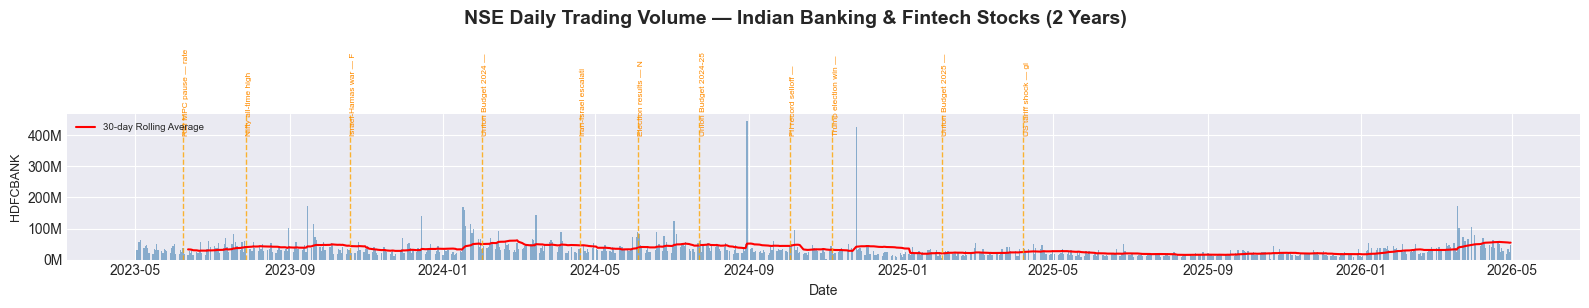

✅ Plot saved to data/processed/volume_overview.png


In [33]:
banking_tickers = [t for t in TICKERS if t in raw_data]

fig, axes = plt.subplots(
    nrows=len(banking_tickers),
    ncols=1,
    figsize=(16, 3 * len(banking_tickers)),
    sharex=True
)

fig.suptitle(
    'NSE Daily Trading Volume — Indian Banking & Fintech Stocks (2 Years)',
    fontsize=14, fontweight='bold', y=1.01
)
axes = np.array(axes).flatten()
for idx, ticker in enumerate(banking_tickers):
    df  = raw_data[ticker]
    ax  = axes[idx]
    
    # Plot raw volume as bar chart
    ax.bar(df.index, df['Volume'],
           color='steelblue', alpha=0.6, width=1)
    
    # Overlay 30-day rolling average
    rolling_avg = df['Volume'].rolling(30).mean()
    ax.plot(df.index, rolling_avg,
            color='red', linewidth=1.5,
            label='30-day Rolling Average')
    
    # Mark known Indian market events
    for event in EVENTS:
        event_date = pd.to_datetime(event['date'])
        if df.index[0] <= event_date <= df.index[-1]:
            ax.axvline(x=event_date,
                      color='orange', linestyle='--',
                      linewidth=1, alpha=0.8)
            ax.annotate(
                event['description'][:20],
                xy=(event_date, df['Volume'].max() * 0.9),
                fontsize=6, color='darkorange', rotation=90
            )
    
    ax.set_ylabel(ticker.replace('.NS', ''), fontsize=9)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M')
    )
    ax.legend(fontsize=7, loc='upper left')

axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.savefig(project_root / 'data' / 'processed' / 'volume_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to data/processed/volume_overview.png")

In [34]:
PRIMARY_TICKER = "HDFCBANK.NS"
df_primary = raw_data[PRIMARY_TICKER].copy()

print(f"PRIMARY STOCK: {PRIMARY_TICKER}")
print(f"{'─' * 45}")
print(f"Date range    : {df_primary.index[0].date()} "
      f"to {df_primary.index[-1].date()}")
print(f"Trading days  : {len(df_primary)}")
print(f"Avg Volume    : {df_primary['Volume'].mean():>15,.0f} shares/day")
print(f"Max Volume    : {df_primary['Volume'].max():>15,.0f} shares/day")
print(f"Min Volume    : {df_primary['Volume'].min():>15,.0f} shares/day")
print(f"Std Dev       : {df_primary['Volume'].std():>15,.0f}")
print(f"Coefficient of")
print(f"Variation     : "
      f"{(df_primary['Volume'].std()/df_primary['Volume'].mean()*100):.1f}%")

print(f"\nFirst 5 rows:")
print(df_primary.head())
print(f"\nLast 5 rows:")
print(df_primary.tail())

PRIMARY STOCK: HDFCBANK.NS
─────────────────────────────────────────────
Date range    : 2023-05-02 to 2026-04-30
Trading days  : 739
Avg Volume    :      33,460,637 shares/day
Max Volume    :     445,342,100 shares/day
Min Volume    :       1,759,692 shares/day
Std Dev       :      29,415,677
Coefficient of
Variation     : 87.9%

First 5 rows:
Price       Close   High    Low   Open    Volume
Date                                            
2023-05-02 811.85 817.50 809.32 812.55  32221184
2023-05-03 814.69 816.06 808.19 810.74  29407270
2023-05-04 831.36 834.56 811.78 811.78  56854638
2023-05-05 782.21 799.20 780.50 788.63  62770416
2023-05-08 791.26 794.10 784.30 786.71  37244524

Last 5 rows:
Price       Close   High    Low   Open    Volume
Date                                            
2026-04-24 784.85 787.60 777.00 777.30  27720358
2026-04-27 789.80 793.00 785.00 787.50  18115375
2026-04-28 782.55 794.50 778.30 785.00  35366803
2026-04-29 779.00 790.00 777.35 785.50  25799963
20

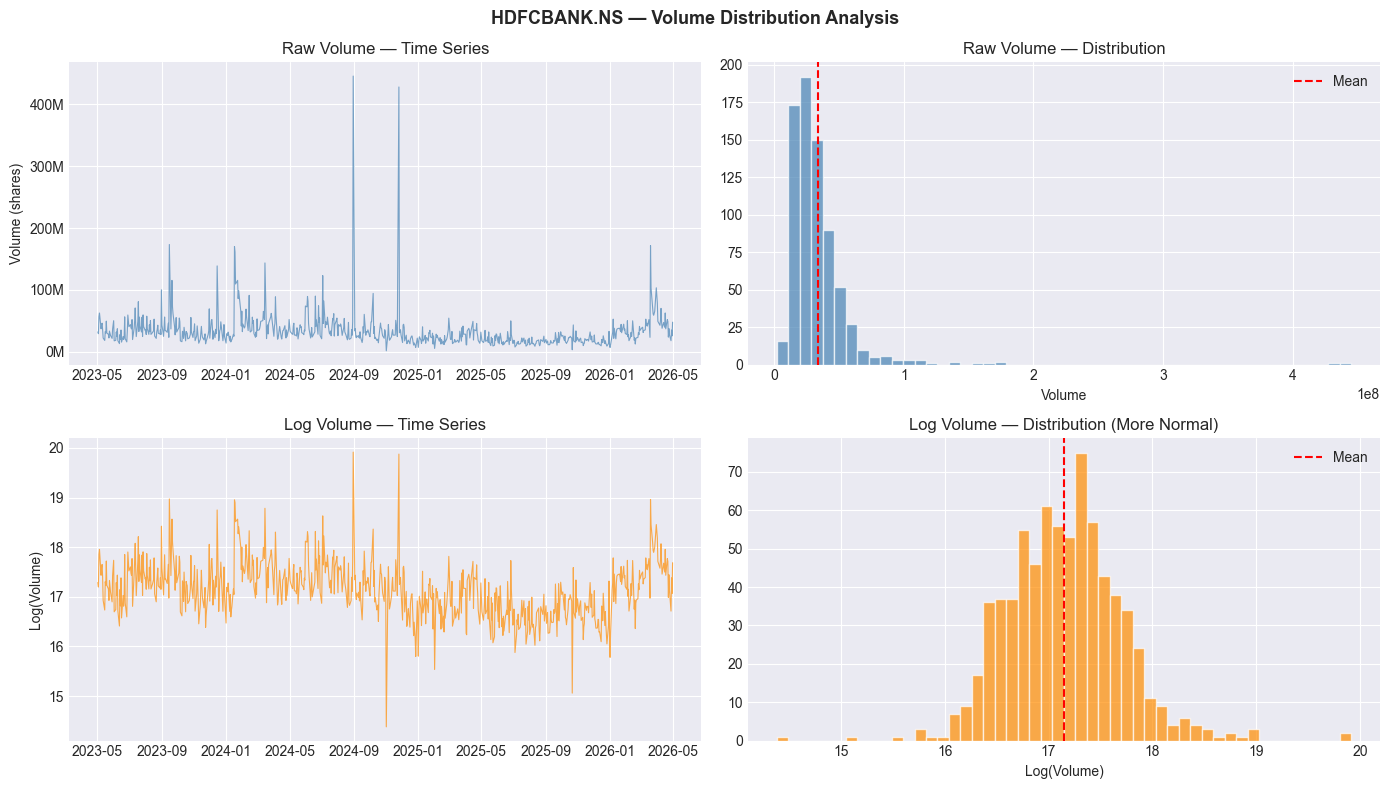

7.9334896657411536
0.3325807773490014


In [37]:

df_primary['Log_Volume'] = np.log(df_primary['Volume'])

# ── Plot: Raw vs Log Volume Distribution ──
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'{PRIMARY_TICKER} — Volume Distribution Analysis',
             fontsize=13, fontweight='bold')

# Raw volume — time series
axes[0, 0].plot(df_primary.index, df_primary['Volume'],
                color='steelblue', alpha=0.7, linewidth=0.8)
axes[0, 0].set_title('Raw Volume — Time Series')
axes[0, 0].set_ylabel('Volume (shares)')
axes[0, 0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

# Raw volume — histogram
axes[0, 1].hist(df_primary['Volume'], bins=50,
                color='steelblue', alpha=0.7, edgecolor='white')
axes[0, 1].set_title('Raw Volume — Distribution')
axes[0, 1].set_xlabel('Volume')
axes[0, 1].axvline(df_primary['Volume'].mean(),
                   color='red', linestyle='--', label='Mean')
axes[0, 1].legend()

# Log volume — time series
axes[1, 0].plot(df_primary.index, df_primary['Log_Volume'],
                color='darkorange', alpha=0.7, linewidth=0.8)
axes[1, 0].set_title('Log Volume — Time Series')
axes[1, 0].set_ylabel('Log(Volume)')

# Log volume — histogram
axes[1, 1].hist(df_primary['Log_Volume'], bins=50,
                color='darkorange', alpha=0.7, edgecolor='white')
axes[1, 1].set_title('Log Volume — Distribution (More Normal)')
axes[1, 1].set_xlabel('Log(Volume)')
axes[1, 1].axvline(df_primary['Log_Volume'].mean(),
                   color='red', linestyle='--', label='Mean')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(project_root / 'data' / 'processed' / 'volume_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"{df_primary['Volume'].skew()}")
print(f"{df_primary['Log_Volume'].skew()}")

We can clearely see that the Log transformattion transforms time series to Normal Distribution. We will be using Log Transformed series going forward.

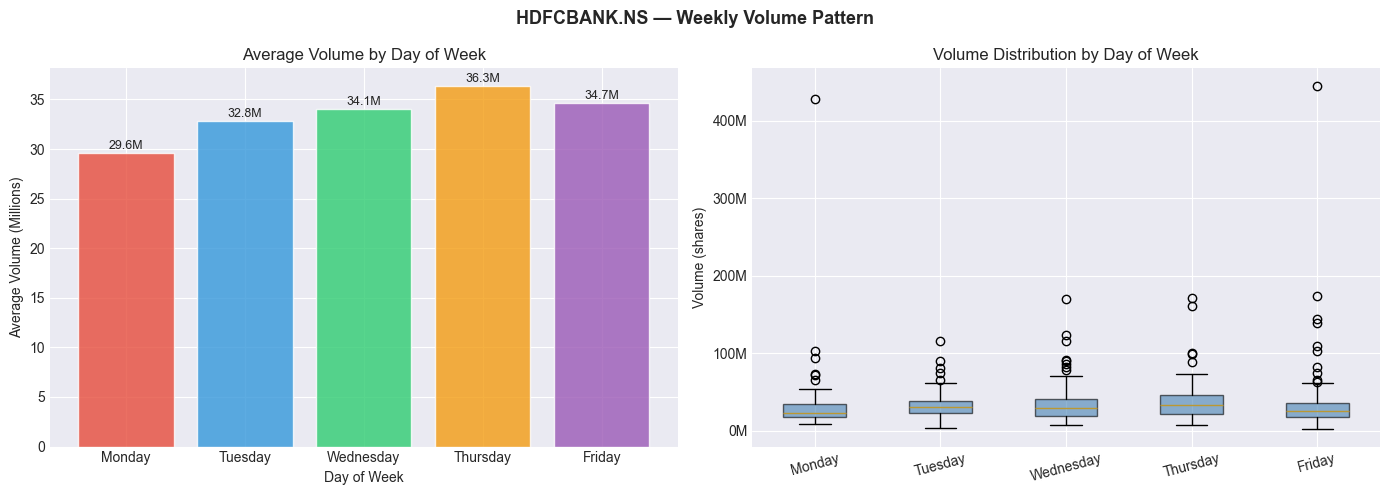

WEEKLY PATTERN ANALYSIS:
DayOfWeek          mean        median
   Monday 29,572,126.68 22,370,201.00
  Tuesday 32,840,354.54 31,134,494.00
Wednesday 34,060,890.56 29,123,650.00
 Thursday 36,316,296.65 33,220,547.00
   Friday 34,657,548.28 26,080,040.00

KEY INSIGHT:
  → Highest volume day : Thursday
  → Lowest volume day  : Monday
  → This weekly pattern IS the seasonality our SARIMA will model


In [44]:
# ─────────────────────────────────────────────
# CELL 11 — Weekly Seasonal Pattern
# ─────────────────────────────────────────────

df_primary['DayOfWeek']    = df_primary.index.day_name()
df_primary['DayOfWeekNum'] = df_primary.index.dayofweek

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# ── Only keep days that actually exist in the data ──
available_days = [d for d in day_order if d in df_primary['DayOfWeek'].values]

weekly_stats = (
    df_primary.groupby('DayOfWeek')['Volume']
    .agg(['mean', 'median', 'std'])
    .reindex(available_days)
    .dropna()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{PRIMARY_TICKER} — Weekly Volume Pattern',
             fontsize=13, fontweight='bold')

# ── Left plot — Mean volume by day ──
bars = axes[0].bar(
    weekly_stats['DayOfWeek'],
    weekly_stats['mean'] / 1e6,
    color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6'][:len(weekly_stats)],
    alpha=0.8,
    edgecolor='white'
)
axes[0].set_title('Average Volume by Day of Week')
axes[0].set_ylabel('Average Volume (Millions)')
axes[0].set_xlabel('Day of Week')

for bar, val in zip(bars, weekly_stats['mean']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{val/1e6:.1f}M',
        ha='center', va='bottom', fontsize=9
    )

# ── Right plot — Boxplot per day ──
# Build list of volume arrays per day — only for available days
volume_by_day = [
    df_primary[df_primary['DayOfWeek'] == day]['Volume'].dropna().values
    for day in available_days
]

axes[1].boxplot(
    volume_by_day,
    positions=range(len(available_days)),  # always matches volume_by_day length
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[1].set_xticks(range(len(available_days)))
axes[1].set_xticklabels(available_days, rotation=15)
axes[1].set_title('Volume Distribution by Day of Week')
axes[1].set_ylabel('Volume (shares)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M')
)

plt.tight_layout()
plt.savefig(
    project_root / 'data' / 'processed' / 'weekly_pattern.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("WEEKLY PATTERN ANALYSIS:")
print(weekly_stats[['DayOfWeek', 'mean', 'median']].to_string(index=False))
print("\nKEY INSIGHT:")
highest_day = weekly_stats.loc[weekly_stats['mean'].idxmax(), 'DayOfWeek']
lowest_day  = weekly_stats.loc[weekly_stats['mean'].idxmin(), 'DayOfWeek']
print(f"  → Highest volume day : {highest_day}")
print(f"  → Lowest volume day  : {lowest_day}")
print("  → This weekly pattern IS the seasonality our SARIMA will model")

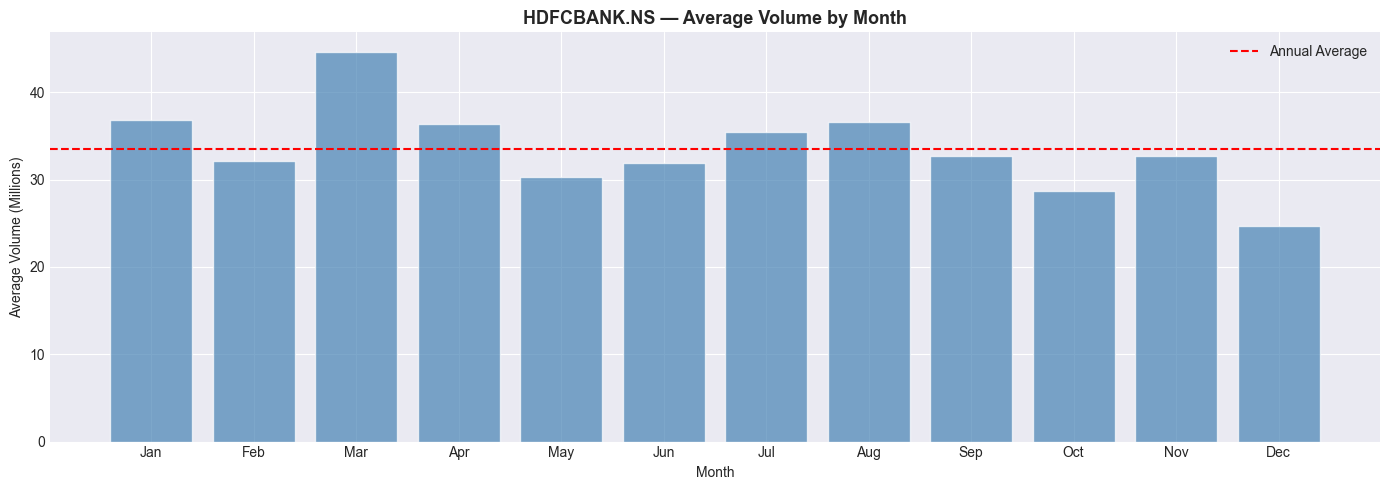

In [46]:
# ─────────────────────────────────────────────
# CELL 12 — Monthly Seasonal Pattern
# ─────────────────────────────────────────────

df_primary['Month'] = df_primary.index.month
df_primary['MonthName'] = df_primary.index.strftime('%b')

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_stats = (
    df_primary.groupby('MonthName')['Volume']
    .mean()
    .reindex(month_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(monthly_stats['MonthName'],
              monthly_stats['Volume'] / 1e6,
              color='steelblue', alpha=0.7, edgecolor='white')

ax.set_title(f'{PRIMARY_TICKER} — Average Volume by Month',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Average Volume (Millions)')
ax.set_xlabel('Month')
ax.axhline(df_primary['Volume'].mean() / 1e6,
           color='red', linestyle='--',
           linewidth=1.5, label='Annual Average')
ax.legend()

plt.tight_layout()
plt.savefig(project_root / 'data' / 'processed' / 'monthly_pattern.png',
            dpi=150, bbox_inches='tight')
plt.show()

We can observ the sp